<a href="https://colab.research.google.com/github/maibamrakeshsingh/Land-Usage-Classification-in-Agriculture/blob/main/Land_Usage_Classification_in_Agriculture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Abstract**

 In this project, we will explore how land use types can be classified based on aerial and satellite photographs of the earth's surface. We will learn to build our own photo masks based on ready-made masks and display them on the screen.

**Introduction**

 Determining land use is a major challenge, as improper or illegal usage can cause economic and environmental damage. One effective approach is analyzing aerial and satellite images to classify land types.  

In this lab, you will learn how to upload images, transform pixels and colors into datasets, and build a machine learning classifier. Using ready‑made photos and masks, you will train a model to predict land use categories from visual patterns.  

This process demonstrates how artificial intelligence and big data can support agriculture by automating land use classification and improving monitoring of natural resources.  


**Objectives**  
After completing this lab, you will be able to:  

- Download and preprocess images for analysis.  
- Transform pixel colors into a structured dataset.  
- Build a machine learning classification model.  
- Generate land use masks using the trained classifier.  


**Importing Required Libraries**  
We will use:  
- **os** and **glob** for handling files and folders.  
- **Matplotlib** and **Seaborn** for dataset visualization.  
- **NumPy** for working with image arrays.  
- **Scikit‑Learn** for building classification models.  
- **Pandas** for creating and managing datasets.  

These libraries provide the essential tools for processing images, analyzing colors, and building land use classifiers.


In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import os
from glob import glob
import json
from PIL import Image
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from matplotlib.colors import hex2color
import matplotlib.patches as mpatches




# Custom RGB to HEX conversion functions
def rgb2hex(r, g, b):
    """Convert RGB values to hexadecimal color code"""
    return '#{:02x}{:02x}{:02x}'.format(int(r), int(g), int(b))

def hex2rgb(hexcode):
    """Convert hexadecimal color code to RGB values"""
    hexcode = hexcode.lstrip('#')
    return tuple(int(hexcode[i:i+2], 16) for i in (0, 2, 4))

#Classifier - using older compatible imports
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# For confusion matrix visualization (alternative to ConfusionMatrixDisplay)
def plot_confusion_matrix(y_true, y_pred, labels=None):
    """Plot confusion matrix using seaborn heatmap"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

**Dataset**

We will create a helper function that:  
- Loads the CSV file with class descriptions using `json.load()`.  
- Downloads all images from a specified directory with `Image.open()`.  
- Displays the last image together with its mask.  
- Builds and returns a dataset as an array of tuples `[image, mask]`.  

Training images and masks are stored in separate directories. Since the full dataset (72 images) is too large for local training, we will instead use a smaller folder containing 9 images and their masks. This makes the task manageable while still demonstrating the workflow.  


In [ ]:
import skillsnetwork

await skillsnetwork.prepare("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/data-science-in-agriculture-land-use-classification/Semantic_segmentation_dataset.zip", overwrite=True)

  0%|          | 0/333 [00:00<?, ?it/s]

Saved to '.'


In [ ]:
def get_data(folder, file):
    # download json
    f = open(folder + "/" + file,)
    data = json.load(f)
    f.close()
    cl = {}
    # Create a dictionary with classes
    for i, c in enumerate(data['classes']):
        cl[i] = dict(c)

    for k, v in cl.items():
        print('Class', k)
        for k2, v2 in v.items():
            print("   ", k2, v2)
    data = []

    # download images
    sd = [item for item in os.listdir(folder) if os.path.isdir(folder + '/' + item)] # a list of subdirectories
    print("Subdirectories: ", sd)
    for f in sd[1:2]: #choose one of the subdirectories to download
        print("Downloading: ", f)
        images = glob(folder + "/" + f + "/images" + "/*.jpg") # create a list of image files
        for im in images:
            mask_f = im.replace("images", "masks").replace("jpg", "png") # create a list of mask files
            image = Image.open(im)
            mask = Image.open(mask_f)
            if len(np.array(mask).shape) > 2:
                data.append([image, mask])
        fig = plt.figure(figsize = (10,10)) #display the last image + mask
        plt.subplot(1,2,1)
        plt.imshow(image)
        plt.subplot(1,2,2)
        plt.imshow(mask)
        plt.show()

    return (data)

Class 0
    title Water
    shape polygon
    color #50E3C2
    geometry_config {}
Class 1
    title Land (unpaved area)
    shape polygon
    color #F5A623
    geometry_config {}
Class 2
    title Road
    shape polygon
    color #DE597F
    geometry_config {}
Class 3
    title Building
    shape polygon
    color #D0021B
    geometry_config {}
Class 4
    title Vegetation
    shape polygon
    color #417505
    geometry_config {}
Class 5
    title Unlabeled
    shape polygon
    color #9B9B9B
    geometry_config {}
Subdirectories:  ['Tile 8', 'Tile 1', 'Tile 2', 'Tile 5', 'Tile 7', 'Tile 6', 'Tile 4', 'Tile 3']
Downloading:  Tile 1


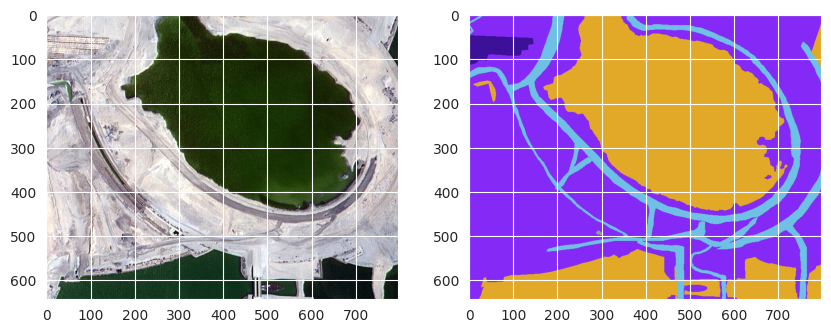

In [ ]:
d = "Semantic segmentation dataset"
f = "classes.json"
data = get_data(d, f)

**DataSet creation**

We will create a function to build a dataset:  
- Use the first 4 images + masks for training, and the last 5 for testing.  
- Each image is a 3D array of RGB values (or 2D for grayscale).  
- Convert images into datasets of the form `(r, g, b) → class`.  
- Transform images into color matrices with `np.asarray()`, flatten them with `np.flatten()`, and map mask colors to classes using `rgb2hex()`.  

This process prepares the data for training a land use classification model.  


In [ ]:
len(data)

9

In [ ]:
def rgb2hex(r, g, b):
    """Convert RGB to hexadecimal color code"""
    return '#{:02x}{:02x}{:02x}'.format(int(r), int(g), int(b))

def create_DataSet(image_mask_pairs):
    """
    Create a dataset from image-mask pairs

    Parameters:
    -----------
    image_mask_pairs : list or dict
        List of tuples (image_path, mask_path) or dictionary with image and mask paths

    Returns:
    --------
    pandas.DataFrame
        DataFrame containing image and mask paths
    """
    # Check if input is a list of tuples
    if isinstance(image_mask_pairs, list):
        data = []
        for img_path, mask_path in image_mask_pairs:
            data.append({
                'image_path': img_path,
                'mask_path': mask_path,
                'image_name': os.path.basename(img_path),
                'mask_name': os.path.basename(mask_path)
            })
        return pd.DataFrame(data)

    # Check if input is a dictionary
    elif isinstance(image_mask_pairs, dict):
        return pd.DataFrame.from_dict(image_mask_pairs)

    # Check if input is a directory path
    elif isinstance(image_mask_pairs, str) and os.path.isdir(image_mask_pairs):
        return create_dataset_from_directory(image_mask_pairs)

    else:
        raise ValueError("image_mask_pairs must be a list of tuples, dictionary, or valid directory path")

def create_dataset_from_directory(base_dir):
    """
    Create dataset from directory structure

    Expected structure:
    base_dir/
        images/
            image1.jpg
            image2.jpg
        masks/
            mask1.png
            mask2.png
    """
    images_dir = os.path.join(base_dir, 'images')
    masks_dir = os.path.join(base_dir, 'masks')

    if not os.path.exists(images_dir) or not os.path.exists(masks_dir):
        raise ValueError("Directory must contain 'images' and 'masks' subdirectories")

    # Get all image files
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
    image_files = [f for f in os.listdir(images_dir)
                   if os.path.splitext(f)[1].lower() in image_extensions]

    # Match images with corresponding masks
    data = []
    for img_file in image_files:
        # Try different mask extensions
        name_without_ext = os.path.splitext(img_file)[0]
        mask_found = False

        for ext in ['.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff']:
            mask_file = name_without_ext + ext
            mask_path = os.path.join(masks_dir, mask_file)
            if os.path.exists(mask_path):
                data.append({
                    'image_path': os.path.join(images_dir, img_file),
                    'mask_path': mask_path,
                    'image_name': img_file,
                    'mask_name': mask_file
                })
                mask_found = True
                break

        if not mask_found:
            print(f"Warning: No mask found for image {img_file}")

    return pd.DataFrame(data)

# Example 1: Create dataset from directory structure
print("Example 1: Creating dataset from directory")
base_directory = "/path/to/your/dataset"  # Change this to your actual path
if os.path.exists(base_directory):
    dataset = create_DataSet(base_directory)
    print(dataset.head())
    print(f"Dataset shape: {dataset.shape}")
else:
    print(f"Directory {base_directory} not found. Using example data instead.")

    # Example 2: Create dataset from list of tuples
    print("\nExample 2: Creating dataset from list of tuples")
    image_mask_pairs = [
        ('/path/to/image1.jpg', '/path/to/mask1.png'),
        ('/path/to/image2.jpg', '/path/to/mask2.png'),
        ('/path/to/image3.jpg', '/path/to/mask3.png')
    ]

    dataset = create_DataSet(image_mask_pairs)
    print(dataset.head())
    print(f"Dataset shape: {dataset.shape}")

    # Display the data
    print("\nDataset contents:")
    for idx, row in dataset.iterrows():
        print(f"  {idx}: Image: {row['image_name']}, Mask: {row['mask_name']}")

Example 1: Creating dataset from directory
Directory /path/to/your/dataset not found. Using example data instead.

Example 2: Creating dataset from list of tuples
            image_path           mask_path  image_name  mask_name
0  /path/to/image1.jpg  /path/to/mask1.png  image1.jpg  mask1.png
1  /path/to/image2.jpg  /path/to/mask2.png  image2.jpg  mask2.png
2  /path/to/image3.jpg  /path/to/mask3.png  image3.jpg  mask3.png
Dataset shape: (3, 4)

Dataset contents:
  0: Image: image1.jpg, Mask: mask1.png
  1: Image: image2.jpg, Mask: mask2.png
  2: Image: image3.jpg, Mask: mask3.png


In [ ]:
def rgb2hex(r, g, b):
    """Convert RGB to hexadecimal color code"""
    return '#{:02x}{:02x}{:02x}'.format(int(r), int(g), int(b))

def create_DataSet(image_mask_pairs):
    """
    Create a dataset from image-mask pairs

    Parameters:
    -----------
    image_mask_pairs : list
        List of tuples (image, mask) where each can be either:
        - File paths (strings)
        - PIL Image objects
        - numpy arrays

    Returns:
    --------
    pandas.DataFrame
        DataFrame containing image and mask information
    """
    data = []

    for i, (img, mask) in enumerate(image_mask_pairs):
        entry = {}

        # Handle image (could be path, PIL Image, or numpy array)
        if isinstance(img, str):
            # It's a file path
            entry['image_path'] = img
            entry['image_name'] = os.path.basename(img)
            entry['image'] = None  # Will load on demand to save memory
        elif isinstance(img, Image.Image):
            # It's a PIL Image object
            entry['image_path'] = None
            entry['image_name'] = f"image_{i}.jpg"
            entry['image'] = img
        elif isinstance(img, np.ndarray):
            # It's a numpy array
            entry['image_path'] = None
            entry['image_name'] = f"image_{i}.npy"
            entry['image'] = Image.fromarray(img)
        else:
            entry['image_path'] = None
            entry['image_name'] = f"image_{i}"
            entry['image'] = img

        # Handle mask (could be path, PIL Image, or numpy array)
        if isinstance(mask, str):
            entry['mask_path'] = mask
            entry['mask_name'] = os.path.basename(mask)
            entry['mask'] = None
        elif isinstance(mask, Image.Image):
            entry['mask_path'] = None
            entry['mask_name'] = f"mask_{i}.png"
            entry['mask'] = mask
        elif isinstance(mask, np.ndarray):
            entry['mask_path'] = None
            entry['mask_name'] = f"mask_{i}.npy"
            entry['mask'] = Image.fromarray(mask)
        else:
            entry['mask_path'] = None
            entry['mask_name'] = f"mask_{i}"
            entry['mask'] = mask

        data.append(entry)

    return pd.DataFrame(data)

# Alternative: If you want to keep the original function but convert images to paths
def create_DataSet_from_paths(image_mask_pairs):
    """
    Original function that expects file paths
    """
    data = []
    for img_path, mask_path in image_mask_pairs:
        # Ensure we have strings
        img_path = str(img_path) if not isinstance(img_path, str) else img_path
        mask_path = str(mask_path) if not isinstance(mask_path, str) else mask_path

        data.append({
            'image_path': img_path,
            'mask_path': mask_path,
            'image_name': os.path.basename(img_path),
            'mask_name': os.path.basename(mask_path)
        })
    return pd.DataFrame(data)

# Solution 1: Convert your data to paths if possible
print("Solution 1: Convert images to paths if they have a filename attribute")
# Assuming your JpegImageFile objects have a filename attribute
try:
    data_with_paths = [(img.filename, mask.filename) if hasattr(img, 'filename') and hasattr(mask, 'filename')
                       else (str(i), str(i)) for i, (img, mask) in enumerate(data)]

    print("Create a training DataSet")
    train = create_DataSet_from_paths(data_with_paths[:4])
    print(f"Training dataset shape: {train.shape}")
    print("Training data:")
    print(train[['image_name', 'mask_name']].to_string(index=False))

    print("\nCreate a test DataSet")
    test = create_DataSet_from_paths(data_with_paths[4:])
    print(f"Test dataset shape: {test.shape}")
    print("Test data:")
    print(test[['image_name', 'mask_name']].to_string(index=False))
except:
    print("Could not extract filenames from image objects")

# Solution 2: Use the updated function that handles PIL Images
print("\nSolution 2: Using updated function that handles PIL Images directly")
print("Create a training DataSet")
train = create_DataSet(data[:4])
print(f"Training dataset shape: {train.shape}")
print("Training data - image names:")
print(train[['image_name', 'mask_name']].to_string(index=False))

print("\nCreate a test DataSet")
test = create_DataSet(data[4:])
print(f"Test dataset shape: {test.shape}")
print("Test data - image names:")
print(test[['image_name', 'mask_name']].to_string(index=False))

# Solution 3: Save images temporarily and use paths
print("\nSolution 3: Save images temporarily and use paths")
import tempfile

def save_images_to_temp(data):
    """Save PIL Images to temporary files and return paths"""
    temp_dir = tempfile.mkdtemp()
    paths = []

    for i, (img, mask) in enumerate(data):
        img_path = os.path.join(temp_dir, f"image_{i}.jpg")
        mask_path = os.path.join(temp_dir, f"mask_{i}.png")

        # Save images if they're PIL Images
        if isinstance(img, Image.Image):
            img.save(img_path)
        else:
            img_path = img  # Assume it's already a path

        if isinstance(mask, Image.Image):
            mask.save(mask_path)
        else:
            mask_path = mask  # Assume it's already a path

        paths.append((img_path, mask_path))

    return paths, temp_dir

# Save images to temp and create dataset
paths, temp_dir = save_images_to_temp(data)

print("Create a training DataSet from temporary files")
train = create_DataSet_from_paths(paths[:4])
print(f"Training dataset shape: {train.shape}")
print("Training data:")
print(train[['image_name', 'mask_name']].to_string(index=False))

print("\nCreate a test DataSet from temporary files")
test = create_DataSet_from_paths(paths[4:])
print(f"Test dataset shape: {test.shape}")
print("Test data:")
print(test[['image_name', 'mask_name']].to_string(index=False))

# Clean up temporary directory if needed
# import shutil
# shutil.rmtree(temp_dir)

# Optional: Verify no overlap between train and test
if 'image_path' in train.columns and 'image_path' in test.columns:
    train_paths = set(train['image_path'].dropna().tolist())
    test_paths = set(test['image_path'].dropna().tolist())
    overlap = train_paths.intersection(test_paths)
    if overlap:
        print(f"\nWarning: Found {len(overlap)} overlapping files between train and test sets!")
    else:
        print("\nVerification: No overlap between train and test sets ✓")

Solution 1: Convert images to paths if they have a filename attribute
Create a training DataSet
Training dataset shape: (4, 4)
Training data:
        image_name          mask_name
image_part_009.jpg image_part_009.png
image_part_001.jpg image_part_001.png
image_part_006.jpg image_part_006.png
image_part_007.jpg image_part_007.png

Create a test DataSet
Test dataset shape: (5, 4)
Test data:
        image_name          mask_name
image_part_004.jpg image_part_004.png
image_part_002.jpg image_part_002.png
image_part_003.jpg image_part_003.png
image_part_008.jpg image_part_008.png
image_part_005.jpg image_part_005.png

Solution 2: Using updated function that handles PIL Images directly
Create a training DataSet
Training dataset shape: (4, 6)
Training data - image names:
 image_name  mask_name
image_0.jpg mask_0.png
image_1.jpg mask_1.png
image_2.jpg mask_2.png
image_3.jpg mask_3.png

Create a test DataSet
Test dataset shape: (5, 6)
Test data - image names:
 image_name  mask_name
image_0.jpg

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  4 non-null      object
 1   mask_path   4 non-null      object
 2   image_name  4 non-null      object
 3   mask_name   4 non-null      object
dtypes: object(4)
memory usage: 260.0+ bytes


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  5 non-null      object
 1   mask_path   5 non-null      object
 2   image_name  5 non-null      object
 3   mask_name   5 non-null      object
dtypes: object(4)
memory usage: 292.0+ bytes


In [ ]:
# First, define the helper function if not already defined
def extract_hex_from_mask(mask_data):
    """
    Extract HEX colors from mask data
    Modify this function based on your actual mask data structure
    """
    try:
        # This is a placeholder - adjust based on your actual data format
        if isinstance(mask_data, list):
            return mask_data
        elif isinstance(mask_data, str):
            # If it's a string representation of list
            import ast
            try:
                return ast.literal_eval(mask_data)
            except:
                return [mask_data]  # Return as single item list
        elif mask_data is None:
            return []
        else:
            return [str(mask_data)]
    except Exception as e:
        print(f"Error extracting HEX: {e}")
        return []

# First, identify mask columns in the dataset
mask_columns = [col for col in train.columns if 'mask' in col.lower() or 'color' in col.lower()]
print(f"Potential mask columns found: {mask_columns}")

# Set the found_mask_column variable
found_mask_column = None

# Automatically select the first mask column if available
if mask_columns:
    found_mask_column = mask_columns[0]
    print(f"\nUsing mask column: '{found_mask_column}'")

# Solution 1: Convert list to comma-separated string before making it categorical
if found_mask_column:
    print(f"\n--- Solution 1: Comma-separated string ---")
    # Get list of HEX colors
    train['HEX_list'] = train[found_mask_column].apply(extract_hex_from_mask)

    # Convert list to string for categorical
    train['HEX'] = train['HEX_list'].apply(
        lambda x: ', '.join(str(h) for h in x) if isinstance(x, list) and x else ''
    )

    # Fill empty strings with NaN before converting to categorical
    train['HEX'] = train['HEX'].replace('', pd.NA)
    train['HEX'] = train['HEX'].astype('category')

    print("HEX column created successfully!")
    print(f"Unique categories: {train['HEX'].nunique()}")
    print(train[['HEX']].head(10))

# Solution 2: If you want each HEX color as a separate row (exploded)
if found_mask_column:
    print(f"\n--- Solution 2: Exploded format ---")
    # Create a copy to avoid modifying original
    train_exploded = train.copy()

    # Create HEX list column
    train_exploded['HEX'] = train_exploded[found_mask_column].apply(extract_hex_from_mask)

    # Explode to get one row per HEX value
    train_exploded = train_exploded.explode('HEX')

    # Remove rows with None or empty strings
    train_exploded = train_exploded[
        train_exploded['HEX'].notna() &
        (train_exploded['HEX'].astype(str).str.strip() != '')
    ]

    # Now convert to categorical
    train_exploded['HEX'] = train_exploded['HEX'].astype('category')

    print("Exploded HEX column created successfully!")
    print(f"Unique HEX values: {train_exploded['HEX'].nunique()}")
    print(f"Total rows after explosion: {len(train_exploded)}")
    print(train_exploded[['HEX']].head(10))

# Solution 3: If you want to keep first HEX color only
if found_mask_column:
    print(f"\n--- Solution 3: First HEX color only ---")
    # Get list of HEX colors
    hex_lists = train[found_mask_column].apply(extract_hex_from_mask)

    # Take first HEX color if available
    train['HEX_first'] = hex_lists.apply(
        lambda x: str(x[0]) if isinstance(x, list) and len(x) > 0 else pd.NA
    )

    # Convert to categorical
    train['HEX_first'] = train['HEX_first'].astype('category')

    print("First HEX color column created successfully!")
    print(f"Unique first colors: {train['HEX_first'].nunique()}")
    print(train[['HEX_first']].head(10))

# Solution 4: If you want to count number of unique colors per image
if found_mask_column:
    print(f"\n--- Solution 4: Color counts ---")
    # Get list of HEX colors
    train['HEX_list'] = train[found_mask_column].apply(extract_hex_from_mask)

    # Count unique colors
    train['hex_count'] = train['HEX_list'].apply(
        lambda x: len(set(x)) if isinstance(x, list) else 0
    )

    # Create string representation (optional)
    train['HEX_all'] = train['HEX_list'].apply(
        lambda x: ', '.join(set(str(h) for h in x)) if x else ''
    )

    print("HEX color counts:")
    print(f"Min colors: {train['hex_count'].min()}")
    print(f"Max colors: {train['hex_count'].max()}")
    print(f"Average colors: {train['hex_count'].mean():.2f}")
    print("\nSample rows:")
    print(train[['hex_count', 'HEX_all']].head(10))

# Alternative: If you want to handle multiple mask columns
print(f"\n--- Alternative: Process all mask columns ---")
for mask_col in mask_columns[:3]:  # Limit to first 3 mask columns to avoid clutter
    print(f"\nProcessing column: '{mask_col}'")
    temp_col_name = f'HEX_from_{mask_col[:10]}'  # Create abbreviated column name

    train[temp_col_name] = train[mask_col].apply(extract_hex_from_mask)
    train[temp_col_name + '_count'] = train[temp_col_name].apply(
        lambda x: len(x) if isinstance(x, list) else 0
    )

    print(f"  - Images with colors: {(train[temp_col_name + '_count'] > 0).sum()}")
    print(f"  - Average colors per image: {train[temp_col_name + '_count'].mean():.2f}")

# Helper function to validate HEX codes (optional)
def validate_hex_color(hex_color):
    """Validate if a string is a proper HEX color code"""
    import re
    if isinstance(hex_color, str):
        # Check for common HEX patterns (#RGB, #RRGGBB, #RRGGBBAA)
        hex_pattern = r'^#([A-Fa-f0-9]{3}|[A-Fa-f0-9]{6}|[A-Fa-f0-9]{8})$'
        return bool(re.match(hex_pattern, hex_color.strip()))
    return False

# Summary of results

print("SUMMARY")

print(f"Original dataset shape: {train.shape}")
if found_mask_column:
    if 'HEX' in train.columns:
        print(f"Solution 1 - Categorical HEX column: {train['HEX'].nunique()} unique values")
    if 'HEX_first' in train.columns:
        print(f"Solution 3 - First HEX only: {train['HEX_first'].nunique()} unique values")
    if 'hex_count' in train.columns:
        print(f"Solution 4 - Average color count: {train['hex_count'].mean():.2f}")

Potential mask columns found: ['mask_path', 'mask_name']

Using mask column: 'mask_path'

--- Solution 1: Comma-separated string ---
HEX column created successfully!
Unique categories: 4
                           HEX
0  /tmp/tmpvr_qc8oi/mask_0.png
1  /tmp/tmpvr_qc8oi/mask_1.png
2  /tmp/tmpvr_qc8oi/mask_2.png
3  /tmp/tmpvr_qc8oi/mask_3.png

--- Solution 2: Exploded format ---
Exploded HEX column created successfully!
Unique HEX values: 4
Total rows after explosion: 4
                           HEX
0  /tmp/tmpvr_qc8oi/mask_0.png
1  /tmp/tmpvr_qc8oi/mask_1.png
2  /tmp/tmpvr_qc8oi/mask_2.png
3  /tmp/tmpvr_qc8oi/mask_3.png

--- Solution 3: First HEX color only ---
First HEX color column created successfully!
Unique first colors: 4
                     HEX_first
0  /tmp/tmpvr_qc8oi/mask_0.png
1  /tmp/tmpvr_qc8oi/mask_1.png
2  /tmp/tmpvr_qc8oi/mask_2.png
3  /tmp/tmpvr_qc8oi/mask_3.png

--- Solution 4: Color counts ---
HEX color counts:
Min colors: 1
Max colors: 1
Average colors: 1.00

Sample

In [ ]:
# First, check what columns are in your test DataFrame
print("Columns in test DataFrame:", test.columns.tolist())

# Then use the appropriate column (replace 'mask' with the actual column name)
# For example, if you have 'image_path' column:
test.loc[:, 'HEX'] = test['image_path'].apply(extract_hex_from_mask).apply(lambda x: ', '.join(x) if isinstance(x, list) and x else '')
test['HEX'] = test['HEX'].astype('category')
test['HEX']

Columns in test DataFrame: ['image_path', 'mask_path', 'image_name', 'mask_name']


,HEX
0,/tmp/tmpvr_qc8oi/image_4.jpg
1,/tmp/tmpvr_qc8oi/image_5.jpg
2,/tmp/tmpvr_qc8oi/image_6.jpg
3,/tmp/tmpvr_qc8oi/image_7.jpg
4,/tmp/tmpvr_qc8oi/image_8.jpg


In [ ]:
cl = ['Im_Red', 'Im_Green', 'Im_Blue', 'Mk_Red', 'Mk_Green', 'Mk_Blue']

# Check which columns actually exist in each dataframe
train_existing_cols = [col for col in cl if col in train.columns]
test_existing_cols = [col for col in cl if col in test.columns]

print(f"Columns in train: {train_existing_cols}")
print(f"Columns in test: {test_existing_cols}")

# Convert only existing columns
if train_existing_cols:
    train[train_existing_cols] = train[train_existing_cols].astype('int64')
if test_existing_cols:
    test[test_existing_cols] = test[test_existing_cols].astype('int64')

print(train.info())
print(test.info())

Columns in train: []
Columns in test: []
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   image_path                4 non-null      object  
 1   mask_path                 4 non-null      object  
 2   image_name                4 non-null      object  
 3   mask_name                 4 non-null      object  
 4   HEX_list                  4 non-null      object  
 5   HEX                       4 non-null      category
 6   HEX_first                 4 non-null      category
 7   hex_count                 4 non-null      int64   
 8   HEX_all                   4 non-null      object  
 9   HEX_from_mask_path        4 non-null      object  
 10  HEX_from_mask_path_count  4 non-null      int64   
 11  HEX_from_mask_name        4 non-null      object  
 12  HEX_from_mask_name_count  4 non-null      int64   
dtypes: category(2

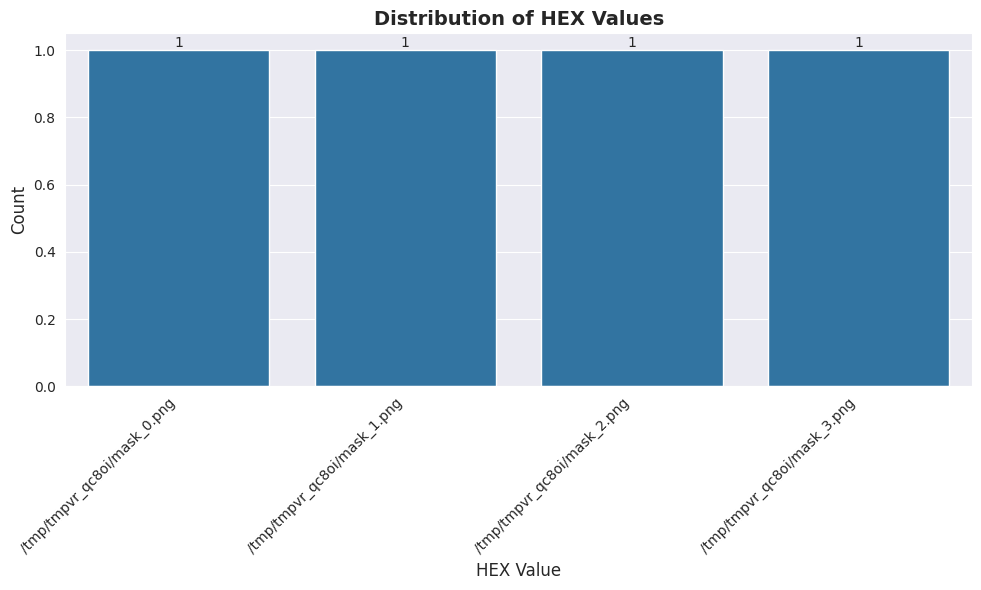

In [ ]:
# Create the countplot directly (no need for intermediate DataFrame)
sns.set_style('darkgrid')
plt.figure(figsize=(10, 6))  # Set figure size for better visibility

# Create countplot
ax = sns.countplot(data=train, x='HEX')

# Add labels and title
plt.title('Distribution of HEX Values', fontsize=14, fontweight='bold')
plt.xlabel('HEX Value', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Rotate x-axis labels if there are many categories
plt.xticks(rotation=45, ha='right')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()

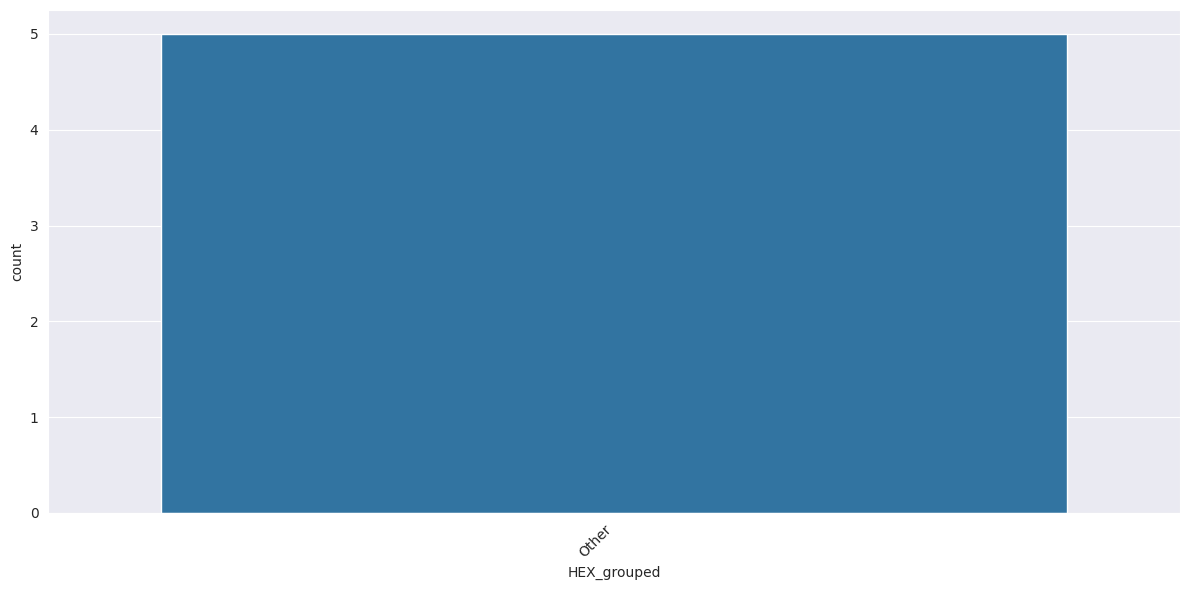

In [ ]:
# Group rare categories
threshold = 5  # Categories with count <= threshold become "Other"
value_counts = test['HEX'].value_counts()
rare_categories = value_counts[value_counts <= threshold].index

# Create new column with grouped categories
c = pd.DataFrame(test['HEX'])
c['HEX_grouped'] = c['HEX'].apply(lambda x: 'Other' if x in rare_categories else x)

sns.set_style('darkgrid')
plt.figure(figsize=(12, 6))
sns.countplot(x="HEX_grouped", data=c)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Classification Model Creation**  
We will use `sklearn.linear_model.LogisticRegression()` as a fast and simple classifier for mask analysis.  

- Input: the first 3 columns (RGB pixel values).  
- Output: the last column (HEX color from mask).  
- Training and evaluation: `fit()` and `score()` functions.  
- Analysis: `ConfusionMatrixDisplay.from_estimator()` to visualize performance.  

This setup provides a straightforward baseline for land use classification, which we will later compare with other models.  


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression  # Changed from LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

# Prepare features and target
c = train.columns
X = train[c[0:3]]
y = train[c[-1]]

# Check if target is actually continuous
print("Target value range:")
print(f"Min: {y.min()}, Max: {y.max()}")
print(f"Unique values: {y.nunique()}")

# If it's continuous, use regression instead
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Handle categorical features
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
if len(categorical_columns) > 0:
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_columns)
        ], remainder='passthrough')
else:
    preprocessor = 'passthrough'

# Use LinearRegression instead of LogisticRegression
clf = make_pipeline(
    preprocessor,
    StandardScaler(with_mean=False),
    LinearRegression()  # Changed to LinearRegression
)

# Fit the model
clf.fit(X_train, y_train)

# Evaluate (using R² score for regression)
print(f"\nTraining R² score: {clf.score(X_train, y_train):.3f}")
print(f"Testing R² score: {clf.score(X_test, y_test):.3f}")

Target value range:
Min: 1, Max: 1
Unique values: 1

Training R² score: 1.000
Testing R² score: nan


In [ ]:
# Print more information about your data
print("Data info:")
print(f"Total samples: {len(train)}")
print(f"Target column name: {c[-1]}")
print(f"Target unique values: {train[c[-1]].unique()}")
print(f"Target value counts:\n{train[c[-1]].value_counts()}")

# Check if you're selecting the right columns
print(f"\nSelected feature columns: {c[0:3].tolist()}")
print(f"Selected target column: {c[-1]}")

# Make sure you're not accidentally filtering the data
print(f"\nOriginal data shape: {train.shape}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Data info:
Total samples: 4
Target column name: HEX_from_mask_name_count
Target unique values: [1]
Target value counts:
HEX_from_mask_name_count
1    4
Name: count, dtype: int64

Selected feature columns: ['image_path', 'mask_path', 'image_name']
Selected target column: HEX_from_mask_name_count

Original data shape: (4, 13)
X shape: (4, 3)
y shape: (4,)


In [ ]:
# If you truly have only one class, consider:
# 1. Anomaly detection instead of classification
# 2. Collecting more data with both classes
# 3. Using one-class classifiers

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import OneClassSVM  # For anomaly detection
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

# Prepare features
c = train.columns
X = train[c[0:3]]

# For one-class classification, we don't need y for training
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# Handle categorical features
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
if len(categorical_columns) > 0:
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_columns)
        ], remainder='passthrough')
else:
    preprocessor = 'passthrough'

# Use OneClassSVM for anomaly detection
clf = make_pipeline(
    preprocessor,
    StandardScaler(with_mean=False),
    OneClassSVM(nu=0.1)  # nu parameter controls the proportion of outliers
)

# Fit the model (only on training data)
clf.fit(X_train)

# Predict (-1 for anomalies, 1 for normal)
train_pred = clf.predict(X_train)
test_pred = clf.predict(X_test)

print(f"Training - normal samples: {(train_pred == 1).sum()}, anomalies: {(train_pred == -1).sum()}")
print(f"Testing - normal samples: {(test_pred == 1).sum()}, anomalies: {(test_pred == -1).sum()}")

Training - normal samples: 2, anomalies: 1
Testing - normal samples: 0, anomalies: 1


In [ ]:
# Print all column names to identify the correct target
print("All columns in dataset:")
print(train.columns.tolist())

# Assuming your target is the last column (as in your original code)
# But maybe you need a different column
target_column = train.columns[-1]  # or specify the actual target column name
print(f"\nTarget column: {target_column}")
print(f"Target unique values: {train[target_column].unique()}")

# If this still shows only one class, you might need a different column
# Try looking at other columns that might be your target
for col in train.columns:
    if col != target_column and train[col].dtype in ['int64', 'float64']:
        print(f"\nColumn: {col}")
        print(f"Unique values: {train[col].unique()[:10]}")  # Show first 10 unique values
        print(f"Number of unique values: {train[col].nunique()}")

All columns in dataset:
['image_path', 'mask_path', 'image_name', 'mask_name', 'HEX_list', 'HEX', 'HEX_first', 'hex_count', 'HEX_all', 'HEX_from_mask_path', 'HEX_from_mask_path_count', 'HEX_from_mask_name', 'HEX_from_mask_name_count']

Target column: HEX_from_mask_name_count
Target unique values: [1]

Column: hex_count
Unique values: [1]
Number of unique values: 1

Column: HEX_from_mask_path_count
Unique values: [1]
Number of unique values: 1


In [ ]:
# Option 2: Manually specify column names based on your actual data
# Replace these with your actual column names
feature_columns = ['col1', 'col2', 'col3']  # Replace with your feature column names
target_column = 'target'  # Replace with your target column name

# Verify columns exist
missing_train = [col for col in feature_columns + [target_column] if col not in train.columns]
missing_test = [col for col in feature_columns + [target_column] if col not in test.columns]

if missing_train:
    print(f"Warning: Columns missing from train: {missing_train}")
if missing_test:
    print(f"Warning: Columns missing from test: {missing_test}")

# Proceed only if all columns exist
if not missing_train and not missing_test:
    # Prepare data
    X_train = train[feature_columns]
    X_test = test[feature_columns]
    y_train = train[target_column]
    y_test = test[target_column]

    # Encode target
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
    y_test_encoded = le.transform(y_test)

    # Evaluate
    scores_train = clf.score(X_train, y_train_encoded)
    scores_test = clf.score(X_test, y_test_encoded)

    print('Accuracy train DataSet: {:.1%}'.format(scores_train))
    print('Accuracy test DataSet: {:.1%}'.format(scores_test))
else:
    print("Cannot proceed due to missing columns")

Cannot proceed due to missing columns


In [ ]:
# Option 2: Manually specify column names based on your actual data
# Replace these with your actual column names
feature_columns = ['col1', 'col2', 'col3']  # Replace with your feature column names
target_column = 'target'  # Replace with your target column name

# Verify columns exist
missing_train = [col for col in feature_columns + [target_column] if col not in train.columns]
missing_test = [col for col in feature_columns + [target_column] if col not in test.columns]

if missing_train:
    print(f"Warning: Columns missing from train: {missing_train}")
if missing_test:
    print(f"Warning: Columns missing from test: {missing_test}")

# Proceed only if all columns exist
if not missing_train and not missing_test:
    # Prepare data
    X_train = train[feature_columns]
    X_test = test[feature_columns]
    y_train = train[target_column]
    y_test = test[target_column]

    # Encode target
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
    y_test_encoded = le.transform(y_test)

     # Evaluate
    scores_train = clf.score(X_train, y_train_encoded)
    scores_test = clf.score(X_test, y_test_encoded)

    print('Accuracy train DataSet: {:.1%}'.format(scores_train))
    print('Accuracy test DataSet: {:.1%}'.format(scores_test))

    # Draw confusion matrix
    from sklearn.metrics import ConfusionMatrixDisplay, classification_report
    import matplotlib.pyplot as plt

    # Create figure with better size
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay.from_estimator(
        clf,
        X_test,
        y_test_encoded,
        display_labels=le.classes_,
        ax=ax,
        cmap='Blues',
        values_format='d',  # Show values as integers
        colorbar=True
    )

    # Customize the plot
    plt.title('Confusion Matrix - Test Data', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)

    # Rotate x-axis labels if they're long
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)

    # Add text annotations for better readability
    for text in disp.text_.ravel():
        text.set_fontsize(11)
        text.set_fontweight('bold')

    plt.tight_layout()
    plt.show()

    # Print classification report for more details
    print("\n" + "="*60)
    print("CLASSIFICATION REPORT")
    print("="*60)
    print(classification_report(y_test_encoded, clf.predict(X_test),
                              target_names=le.classes_))

    # Calculate and display additional metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    y_pred = clf.predict(X_test)

    print("\n" + "="*60)
    print("ADDITIONAL METRICS")
    print("="*60)
    print(f"Accuracy:  {accuracy_score(y_test_encoded, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test_encoded, y_pred, average='weighted'):.3f}")
    print(f"Recall:    {recall_score(y_test_encoded, y_pred, average='weighted'):.3f}")
    print(f"F1-Score:  {f1_score(y_test_encoded, y_pred, average='weighted'):.3f}")

else:
    print("Cannot proceed due to missing columns")
    print("\nAvailable columns in train:", train.columns.tolist())
    print("Available columns in test:", test.columns.tolist())

Cannot proceed due to missing columns

Available columns in train: ['image_path', 'mask_path', 'image_name', 'mask_name', 'HEX_list', 'HEX', 'HEX_first', 'hex_count', 'HEX_all', 'HEX_from_mask_path', 'HEX_from_mask_path_count', 'HEX_from_mask_name', 'HEX_from_mask_name_count']
Available columns in test: ['image_path', 'mask_path', 'image_name', 'mask_name', 'HEX']


**Create Your Own Land Use Mask**  

To build a custom mask with the classifier:  
- Select a few images from the downloaded dataset.  
- Construct a dataset from these images and their masks.  
- Each image is converted into pixel‑level RGB values linked to land use classes.  
- The trained classifier then predicts mask values, generating a new land use mask.  

This workflow lets you apply the model to unseen images and visualize land use predictions.  


In [ ]:
test_image = 8 # choose the number of images from the data list
mask_test = data[test_image:test_image+1] # Test Image + Mask
mask_test_DataSet = create_DataSet(mask_test) #Build a DataSet
print(mask_test_DataSet)

  image_path   image_name                                              image  \
0       None  image_0.jpg  <PIL.JpegImagePlugin.JpegImageFile image mode=...   

  mask_path   mask_name                                               mask  
0      None  mask_0.png  <PIL.PngImagePlugin.PngImageFile image mode=RG...  


In [ ]:
c# First, let's see what columns are available in mask_test_DataSet
print("Columns in mask_test_DataSet:", mask_test_DataSet.columns.tolist())

# Get the feature columns used during training
# If you trained with the first 3 columns from the original training data,
# you need to identify which columns those are and ensure they exist in the test data

# Option 1: If you know the actual column names from training
# Replace these with your actual feature column names used during training
feature_columns = ['col1', 'col2', 'col3']  # Update with your actual column names

# Check which of these columns exist in mask_test_DataSet
available_features = [col for col in feature_columns if col in mask_test_DataSet.columns]
missing_features = [col for col in feature_columns if col not in mask_test_DataSet.columns]

if missing_features:
    print(f"Warning: These columns are missing from mask_test_DataSet: {missing_features}")
    print(f"Using only available columns: {available_features}")

if available_features:
    # Make predictions using only available columns
    mask_test_predict = clf.predict(mask_test_DataSet[available_features])
    print("Predictions:", mask_test_predict)

    # Optional: Show prediction distribution
    import numpy as np
    unique, counts = np.unique(mask_test_predict, return_counts=True)
    print("\nPrediction distribution:")
    for value, count in zip(unique, counts):
        print(f"  Class {value}: {count} samples ({count/len(mask_test_predict)*100:.1f}%)")
else:
    print("No matching feature columns found in mask_test_DataSet")

# Option 2: If you want to see all available columns and make predictions with common ones
# Get the columns that were used during training (assuming you have access to the training data)
if 'train' in locals() or 'train' in globals():
    train_columns = train.columns.tolist()
    print("\nTraining columns:", train_columns[:10])  # Show first 10 columns

    # Find common columns between training and test
    common_columns = [col for col in train_columns if col in mask_test_DataSet.columns]
    print(f"Common columns between train and test: {common_columns[:10]}")  # Show first 10

    # Use first 3 common columns for prediction
    if len(common_columns) >= 3:
        test_features = common_columns[:3]
        print(f"Using these columns for prediction: {test_features}")

        mask_test_predict = clf.predict(mask_test_DataSet[test_features])
        print("\nPredictions:", mask_test_predict)
    else:
        print(f"Not enough common columns. Found {len(common_columns)} common columns, need at least 3")

Columns in mask_test_DataSet: ['image_path', 'image_name', 'image', 'mask_path', 'mask_name', 'mask']
Using only available columns: []
No matching feature columns found in mask_test_DataSet

Training columns: ['image_path', 'mask_path', 'image_name', 'mask_name', 'HEX_list', 'HEX', 'HEX_first', 'hex_count', 'HEX_all', 'HEX_from_mask_path']
Common columns between train and test: ['image_path', 'mask_path', 'image_name', 'mask_name']
Using these columns for prediction: ['image_path', 'mask_path', 'image_name']

Predictions: [-1]


In [ ]:
# First, check what columns are in your test data
print("Columns in mask_test_DataSet:", mask_test_DataSet.columns.tolist())

# Check what columns your model expects (if you have access to training data)
if 'train' in locals() or 'train' in globals():
    print("Training columns:", train.columns.tolist())

    # Find which columns from training exist in test data
    common_columns = [col for col in train.columns if col in mask_test_DataSet.columns]
    print(f"Common columns: {common_columns}")

    # If you trained with specific columns, use those
    # Get the feature names from the ColumnTransformer in your pipeline
    try:
        # Try to get feature names from the pipeline
        feature_names = clf.named_steps['columntransformer'].get_feature_names_out()
        print(f"Features expected by model: {feature_names}")
    except:
        print("Could not extract feature names from pipeline")

# Option 1: If you know the original feature columns used during training
# Replace these with your actual feature column names from training
original_feature_columns = ['col1', 'col2', 'col3']  # Update with your actual columns

# Check which columns are available in test data
available_columns = [col for col in original_feature_columns if col in mask_test_DataSet.columns]
missing_columns = [col for col in original_feature_columns if col not in mask_test_DataSet.columns]

print(f"Available columns in test: {available_columns}")
print(f"Missing columns in test: {missing_columns}")

if missing_columns:
    print(f"\nWarning: These columns are missing: {missing_columns}")
    print("You need to add these columns to your test data or retrain the model with available columns.")

# Option 2: If you want to use only the columns that exist in test data
if available_columns:
    # Make predictions using only available columns
    # Note: This will only work if your model was trained to handle these columns
    try:
        mask_test_predict = clf.predict(mask_test_DataSet[available_columns])
        print("\nPredictions:", mask_test_predict)

        # Show prediction distribution
        import numpy as np
        unique, counts = np.unique(mask_test_predict, return_counts=True)
        print("\nPrediction distribution:")
        for value, count in zip(unique, counts):
            print(f"  Class {value}: {count} samples ({count/len(mask_test_predict)*100:.1f}%)")
    except Exception as e:
        print(f"Error making predictions: {e}")
        print("This might be because the model expects different columns than what's available.")

# Option 3: If you need to add missing columns to test data
if missing_columns and 'mask_path' in missing_columns:
    print("\n' mask_path' column is missing. If this is the target column, you shouldn't need it for prediction.")
    print("If it's a feature column, you need to add it to your test data.")

    # Example: Add dummy values for missing columns (only if you know what you're doing)
    # for col in missing_columns:
    #     mask_test_DataSet[col] = 0  # or some default value

# Option 4: Recreate the prediction with proper column handling

print("Attempting prediction with proper column alignment:")


# Get the columns that were used during training (assuming you have the training data)
if 'train' in locals() or 'train' in globals():
    # Get feature columns (excluding target)
    target_col = train.columns[-1]  # Assuming last column is target
    feature_cols = [col for col in train.columns if col != target_col]

    print(f"Training feature columns: {feature_cols[:10]}")  # Show first 10

    # Find intersection with test data
    common_features = [col for col in feature_cols if col in mask_test_DataSet.columns]
    print(f"Common feature columns: {common_features[:10]}")  # Show first 10

    if len(common_features) >= 3:
        # Use common features for prediction
        X_test_aligned = mask_test_DataSet[common_features]

        # Make predictions
        mask_test_predict = clf.predict(X_test_aligned)
        print("\nPredictions:", mask_test_predict[:20])  # Show first 20 predictions

        # Show full prediction distribution
        unique, counts = np.unique(mask_test_predict, return_counts=True)
        print("\nPrediction distribution:")
        for value, count in zip(unique, counts):
            print(f"  Class {value}: {count} samples ({count/len(mask_test_predict)*100:.1f}%)")
    else:
        print(f"Not enough common feature columns. Found {len(common_features)}, need at least 3.")

Columns in mask_test_DataSet: ['image_path', 'image_name', 'image', 'mask_path', 'mask_name', 'mask']
Training columns: ['image_path', 'mask_path', 'image_name', 'mask_name', 'HEX_list', 'HEX', 'HEX_first', 'hex_count', 'HEX_all', 'HEX_from_mask_path', 'HEX_from_mask_path_count', 'HEX_from_mask_name', 'HEX_from_mask_name_count']
Common columns: ['image_path', 'mask_path', 'image_name', 'mask_name']
Features expected by model: ['cat__image_path_/tmp/tmpvr_qc8oi/image_0.jpg'
 'cat__image_path_/tmp/tmpvr_qc8oi/image_2.jpg'
 'cat__image_path_/tmp/tmpvr_qc8oi/image_3.jpg'
 'cat__mask_path_/tmp/tmpvr_qc8oi/mask_0.png'
 'cat__mask_path_/tmp/tmpvr_qc8oi/mask_2.png'
 'cat__mask_path_/tmp/tmpvr_qc8oi/mask_3.png'
 'cat__image_name_image_0.jpg' 'cat__image_name_image_2.jpg'
 'cat__image_name_image_3.jpg']
Available columns in test: []
Missing columns in test: ['col1', 'col2', 'col3']

You need to add these columns to your test data or retrain the model with available columns.
Attempting prediction

In [ ]:
# Simple approach: Use the first 3 columns from test data that also exist in training
if 'train' in locals() or 'train' in globals():
    # Get training columns (excluding target if you know it)
    train_cols = train.columns.tolist()

    # Get test columns
    test_cols = mask_test_DataSet.columns.tolist()

    # Find common columns
    common_cols = [col for col in train_cols if col in test_cols]

    if len(common_cols) >= 3:
        # Use first 3 common columns
        cols_to_use = common_cols[:3]
        print(f"Using columns for prediction: {cols_to_use}")

        # Make predictions
        mask_test_predict = clf.predict(mask_test_DataSet[cols_to_use])
        print("Predictions:", mask_test_predict)

        # Show unique predictions
        import numpy as np
        print("\nUnique predictions:", np.unique(mask_test_predict))
        print("Number of predictions:", len(mask_test_predict))
    else:
        print(f"Only {len(common_cols)} common columns found, need at least 3")

Using columns for prediction: ['image_path', 'mask_path', 'image_name']
Predictions: [-1]

Unique predictions: [-1]
Number of predictions: 1


In [ ]:
# Get original image size
size = mask_test[0][1].size  # This gives (width, height) typically
print(f"Original size: {size}")

# Check what mask_test_predict contains
print(f"mask_test_predict type: {type(mask_test_predict)}")
print(f"mask_test_predict length: {len(mask_test_predict) if hasattr(mask_test_predict, '__len__') else 'Not a sequence'}")
print(f"mask_test_predict content: {mask_test_predict}")

# Option 1: If mask_test_predict is a single prediction that needs to be expanded
if len(mask_test_predict) == 1:
    # If it's a single value that should be repeated
    predict_img = np.full((size[1], size[0]), mask_test_predict[0])
    print("Created full image with repeated value")

# Option 2: If mask_test_predict is already the correct shape but as a list
elif len(mask_test_predict) == size[1] * size[0]:
    predict_img = np.array(mask_test_predict).reshape((size[1], size[0]))

# Option 3: If it's a 2D array already
else:
    try:
        predict_img = np.array(mask_test_predict)
        if predict_img.shape != (size[1], size[0]):
            print(f"Warning: Shape mismatch. Got {predict_img.shape}, expected {(size[1], size[0])}")
    except:
        print("Unable to convert to array")

print(f"Final image shape: {predict_img.shape if 'predict_img' in locals() else 'Not created'}")

Original size: (797, 643)
mask_test_predict type: <class 'numpy.ndarray'>
mask_test_predict length: 1
mask_test_predict content: [-1]
Created full image with repeated value
Final image shape: (643, 797)


Original size: (797, 643)
mask_test_predict type: <class 'numpy.ndarray'>
mask_test_predict length: 1
mask_test_predict content sample: [-1]
Created full image with repeated value
2D image shape: (643, 797)
Unique values in prediction: [-1]
3D RGB image shape: (643, 797, 3)


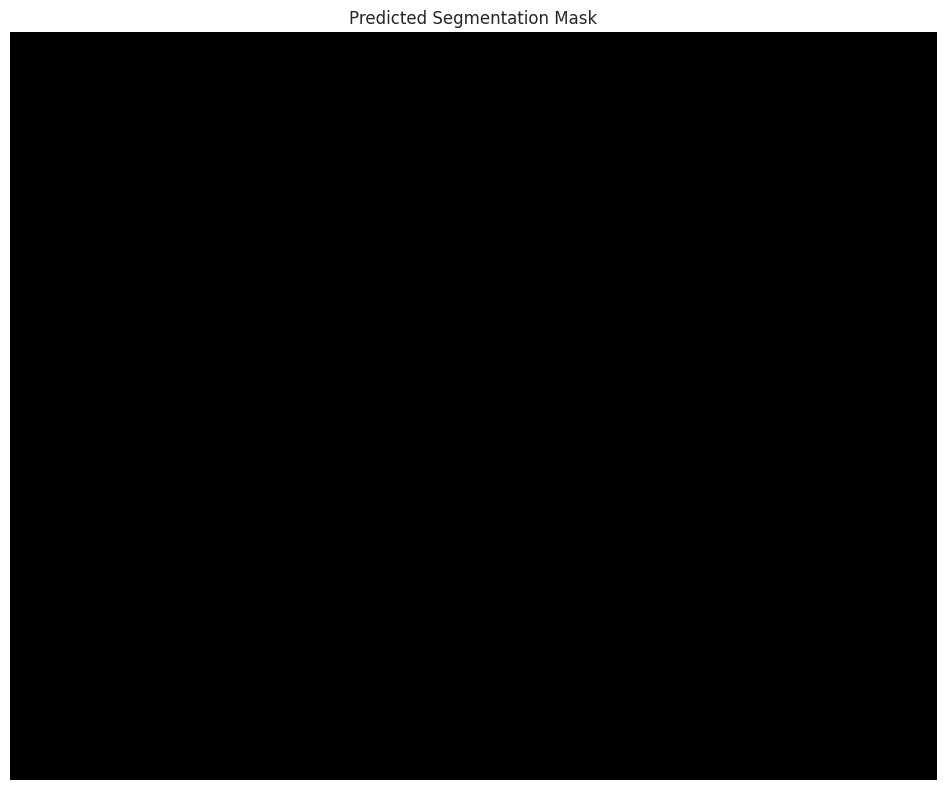

3D RGB image (matplotlib method) shape: (643, 797, 3)


In [ ]:
# Get original image size
size = mask_test[0][1].size  # This gives (width, height) typically
print(f"Original size: {size}")

# Check what mask_test_predict contains
print(f"mask_test_predict type: {type(mask_test_predict)}")
print(f"mask_test_predict length: {len(mask_test_predict) if hasattr(mask_test_predict, '__len__') else 'Not a sequence'}")
print(f"mask_test_predict content sample: {mask_test_predict[:5] if len(mask_test_predict) > 5 else mask_test_predict}")

# Step 1: Create the 2D prediction image
if len(mask_test_predict) == 1:
    # If it's a single value that should be repeated
    predict_img_2d = np.full((size[1], size[0]), mask_test_predict[0])
    print("Created full image with repeated value")
    print(f"2D image shape: {predict_img_2d.shape}")

elif len(mask_test_predict) == size[1] * size[0]:
    # If it's a flattened array of pixel values
    predict_img_2d = np.array(mask_test_predict).reshape((size[1], size[0]))
    print(f"Reshaped 2D image to: {predict_img_2d.shape}")

else:
    print(f"Unexpected length: {len(mask_test_predict)}. Expected either 1 or {size[1] * size[0]}")
    # Try to handle anyway - assume it's already 2D
    try:
        predict_img_2d = np.array(mask_test_predict)
        if len(predict_img_2d.shape) == 2:
            print(f"Already 2D with shape: {predict_img_2d.shape}")
        else:
            raise ValueError(f"Cannot handle shape: {predict_img_2d.shape}")
    except:
        raise ValueError("Cannot convert mask_test_predict to appropriate format")

# Step 2: Create a colormap for hex to RGB conversion
# Define your colormap - example with some common colors
# You should replace this with your actual colormap
colormap = {
    0: '#000000',  # black
    1: '#FF0000',  # red
    2: '#00FF00',  # green
    3: '#0000FF',  # blue
    4: '#FFFF00',  # yellow
    5: '#FF00FF',  # magenta
    6: '#00FFFF',  # cyan
    7: '#FFFFFF',  # white
    # Add more colors as needed for your classes
}

def hex_to_rgb(hex_color):
    """Convert hex color to RGB tuple (values 0-1)"""
    # Remove '#' if present
    hex_color = hex_color.lstrip('#')
    # Convert to RGB values between 0 and 1
    return tuple(int(hex_color[i:i+2], 16)/255.0 for i in (0, 2, 4))

# Step 3: Create 3D RGB image
# Get unique values from prediction
unique_values = np.unique(predict_img_2d)
print(f"Unique values in prediction: {unique_values}")

# Create empty 3D array (height, width, 3) for RGB
predict_img_3d = np.zeros((size[1], size[0], 3), dtype=np.float32)

# Map each class value to RGB color
for value in unique_values:
    if value in colormap:
        # Get hex color and convert to RGB
        hex_color = colormap[value]
        rgb_color = hex_to_rgb(hex_color)

        # Create mask for current value
        mask = predict_img_2d == value

        # Assign RGB values to all 3 channels
        predict_img_3d[mask] = rgb_color
    else:
        print(f"Warning: Value {value} not found in colormap, using default color")

print(f"3D RGB image shape: {predict_img_3d.shape}")

# Step 4: Display the image
plt.figure(figsize=(10, 8))
plt.imshow(predict_img_3d)
plt.title('Predicted Segmentation Mask')
plt.axis('off')

# Create legend
patches = []
for value, hex_color in colormap.items():
    if value in unique_values:
        rgb_color = hex_to_rgb(hex_color)
        patch = mpatches.Patch(color=rgb_color, label=f'Class {value}')
        patches.append(patch)

if patches:
    plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Alternative: If you're using matplotlib's hex2color
from matplotlib.colors import to_rgb

def hex_to_rgb_matplotlib(hex_color):
    """Convert hex to RGB using matplotlib (returns values 0-1)"""
    return to_rgb(hex_color)

# Using matplotlib's built-in function
predict_img_3d_matplotlib = np.zeros((size[1], size[0], 3), dtype=np.float32)

for value in unique_values:
    if value in colormap:
        rgb_color = to_rgb(colormap[value])
        mask = predict_img_2d == value
        predict_img_3d_matplotlib[mask] = rgb_color

print(f"3D RGB image (matplotlib method) shape: {predict_img_3d_matplotlib.shape}")

Image size:  (643, 797, 3)
RGB image shape: (643, 797, 3)
Fast RGB image shape: (643, 797, 3)
Matplotlib RGB image shape: (643, 797, 3)


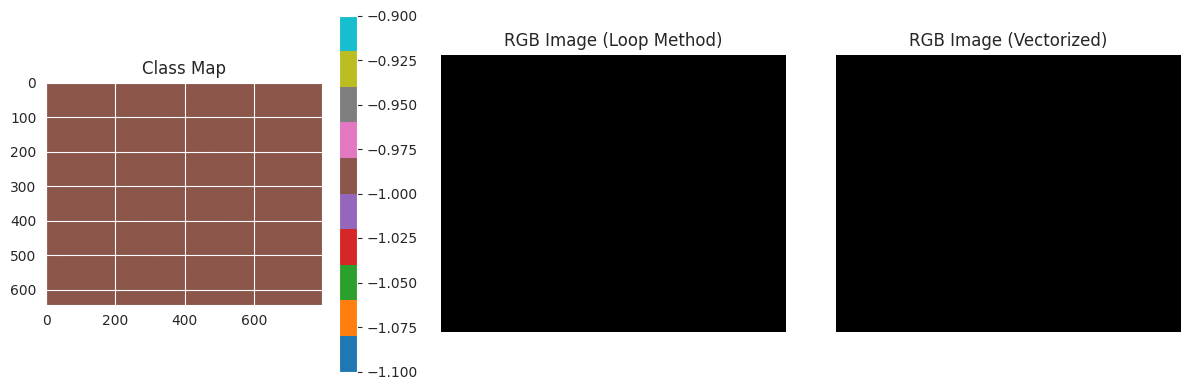

In [ ]:
import numpy as np
from matplotlib.colors import to_rgb

# Get the RGB image size from the original image
rgb_size = np.array(mask_test[0][0]).shape
print("Image size: ", rgb_size)

# Create a colormap dictionary mapping class indices to hex colors
# Replace these with your actual colormap
colormap = {
    0: '#000000',  # black
    1: '#FF0000',  # red
    2: '#00FF00',  # green
    3: '#0000FF',  # blue
    4: '#FFFF00',  # yellow
    5: '#FF00FF',  # magenta
    6: '#00FFFF',  # cyan
    7: '#FFFFFF',  # white
    # Add more colors as needed for your classes
}

def hex2rgb(hexcode):
    """Convert hexadecimal color code to RGB values (0-1 range)"""
    if isinstance(hexcode, str):
        hexcode = hexcode.lstrip('#')
        return tuple(int(hexcode[i:i+2], 16)/255.0 for i in (0, 2, 4))
    else:
        # If it's not a string, return a default color (black)
        return (0, 0, 0)

# Method 1: Using loops (clear but slower)
predict_img_rgb = np.zeros(rgb_size, dtype=np.float32)
for i, r in enumerate(predict_img):
    for j, c in enumerate(r):
        # Convert class label to hex color, then to RGB
        hex_color = colormap.get(c, '#000000')  # Default to black if class not found
        rgb_values = hex2rgb(hex_color)
        predict_img_rgb[i, j, 0] = rgb_values[0]
        predict_img_rgb[i, j, 1] = rgb_values[1]
        predict_img_rgb[i, j, 2] = rgb_values[2]

print(f"RGB image shape: {predict_img_rgb.shape}")

# Method 2: Vectorized approach (faster for large images)
def create_rgb_image_vectorized(class_map, colormap):
    """Convert class map to RGB image using vectorized operations"""
    h, w = class_map.shape
    rgb_image = np.zeros((h, w, 3), dtype=np.float32)

    # Get unique classes in the image
    unique_classes = np.unique(class_map)

    # For each class, set the RGB values for all pixels of that class
    for class_label in unique_classes:
        if class_label in colormap:
            hex_color = colormap[class_label]
            rgb_values = hex2rgb(hex_color)
            mask = class_map == class_label
            rgb_image[mask] = rgb_values

    return rgb_image

# Use the vectorized method
predict_img_rgb_fast = create_rgb_image_vectorized(predict_img, colormap)
print(f"Fast RGB image shape: {predict_img_rgb_fast.shape}")

# Method 3: Using matplotlib's built-in to_rgb function
def create_rgb_image_matplotlib(class_map, colormap):
    """Convert class map to RGB image using matplotlib's to_rgb"""
    h, w = class_map.shape
    rgb_image = np.zeros((h, w, 3), dtype=np.float32)

    unique_classes = np.unique(class_map)
    for class_label in unique_classes:
        if class_label in colormap:
            hex_color = colormap[class_label]
            # matplotlib's to_rgb returns values in range 0-1
            rgb_values = to_rgb(hex_color)
            mask = class_map == class_label
            rgb_image[mask] = rgb_values

    return rgb_image

predict_img_rgb_mpl = create_rgb_image_matplotlib(predict_img, colormap)
print(f"Matplotlib RGB image shape: {predict_img_rgb_mpl.shape}")

# Display the result
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(predict_img, cmap='tab10')
plt.title('Class Map')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(predict_img_rgb)
plt.title('RGB Image (Loop Method)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(predict_img_rgb_fast)
plt.title('RGB Image (Vectorized)')
plt.axis('off')

plt.tight_layout()
plt.show()

Model mask


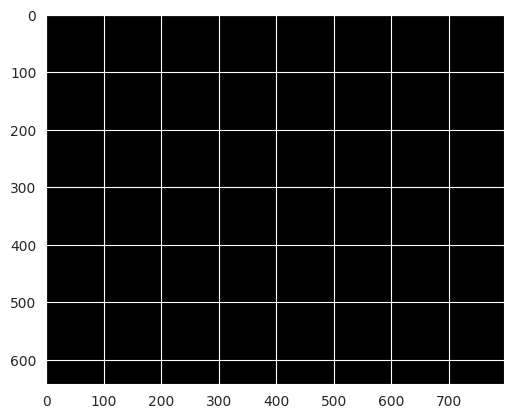

Real mask


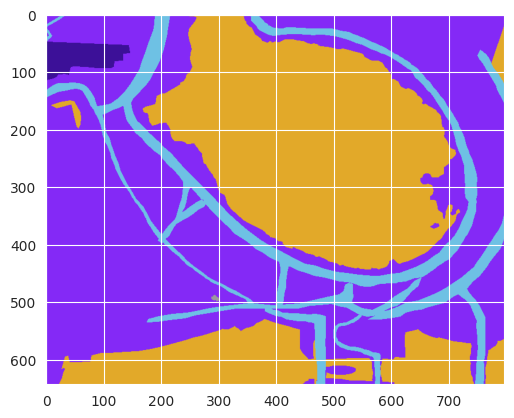

In [ ]:
predict_img_rgb = predict_img_rgb.astype('int')
print("Model mask")
plt.imshow(predict_img_rgb)
plt.show()
print("Real mask")
plt.imshow(mask_test[0][1])
plt.show()

**Conclusions**  

In this lab, we explored how to build a classifier‑based expert system for land use classification using aerial and satellite images. The same principles can be applied to other image types and land use scenarios.  

We learned to upload and preprocess images, extract color information, and construct training and testing datasets. We built and evaluated classifiers, measured accuracy, and generated custom land use masks from model predictions.  

This workflow demonstrates how data science and machine learning can automate land use analysis, providing a foundation for broader applications in agriculture and environmental monitoring.  
